In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import struct, random, os
from array import array
from os.path import join
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)


print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [5]:
# list all input files
for dirname, _, filenames in os.walk("C:\\git\\ML-hands-on-notebooks\\data\\mnist"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\git\ML-hands-on-notebooks\data\mnist\t10k-images.idx3-ubyte.zip
C:\git\ML-hands-on-notebooks\data\mnist\t10k-labels.idx1-ubyte
C:\git\ML-hands-on-notebooks\data\mnist\train-images.idx3-ubyte.zip
C:\git\ML-hands-on-notebooks\data\mnist\train-labels.idx1-ubyte
C:\git\ML-hands-on-notebooks\data\mnist\t10k-images.idx3-ubyte\t10k-images.idx3-ubyte
C:\git\ML-hands-on-notebooks\data\mnist\train-images.idx3-ubyte\train-images.idx3-ubyte


In [9]:
class MnistDataloader:
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath     = test_images_filepath
        self.test_labels_filepath     = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as f:
            magic, size = struct.unpack(">II", f.read(8))
            if magic != 2049:
                raise ValueError(f"Bad magic number: {magic}")
            labels = array("B", f.read())

        with open(images_filepath, 'rb') as f:
            magic, size, rows, cols = struct.unpack(">IIII", f.read(16))
            if magic != 2051:
                raise ValueError(f"Bad magic number: {magic}")
            image_data = array("B", f.read())

        images = []
        for i in range(size):
            img = np.array(image_data[i*rows*cols : (i+1)*rows*cols])
            images.append(img.reshape(rows, cols))

        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(
            self.training_images_filepath, self.training_labels_filepath)
        x_test,  y_test  = self.read_images_labels(
            self.test_images_filepath,     self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

['C:\\git\\ML-hands-on-notebooks\\data\\mnist\\train-images.idx3-ubyte']
['C:\\git\\ML-hands-on-notebooks\\data\\mnist\\train-labels.idx1-ubyte']
['C:\\git\\ML-hands-on-notebooks\\data\\mnist\\t10k-images.idx3-ubyte']
['C:\\git\\ML-hands-on-notebooks\\data\\mnist\\t10k-labels.idx1-ubyte']
Files resolved:
  C:\git\ML-hands-on-notebooks\data\mnist\train-images.idx3-ubyte
  C:\git\ML-hands-on-notebooks\data\mnist\train-labels.idx1-ubyte
  C:\git\ML-hands-on-notebooks\data\mnist\t10k-images.idx3-ubyte
  C:\git\ML-hands-on-notebooks\data\mnist\t10k-labels.idx1-ubyte

Train images : 60000  |  labels: 60000
Test  images : 10000   |  labels: 10000
Image shape  : (28, 28)


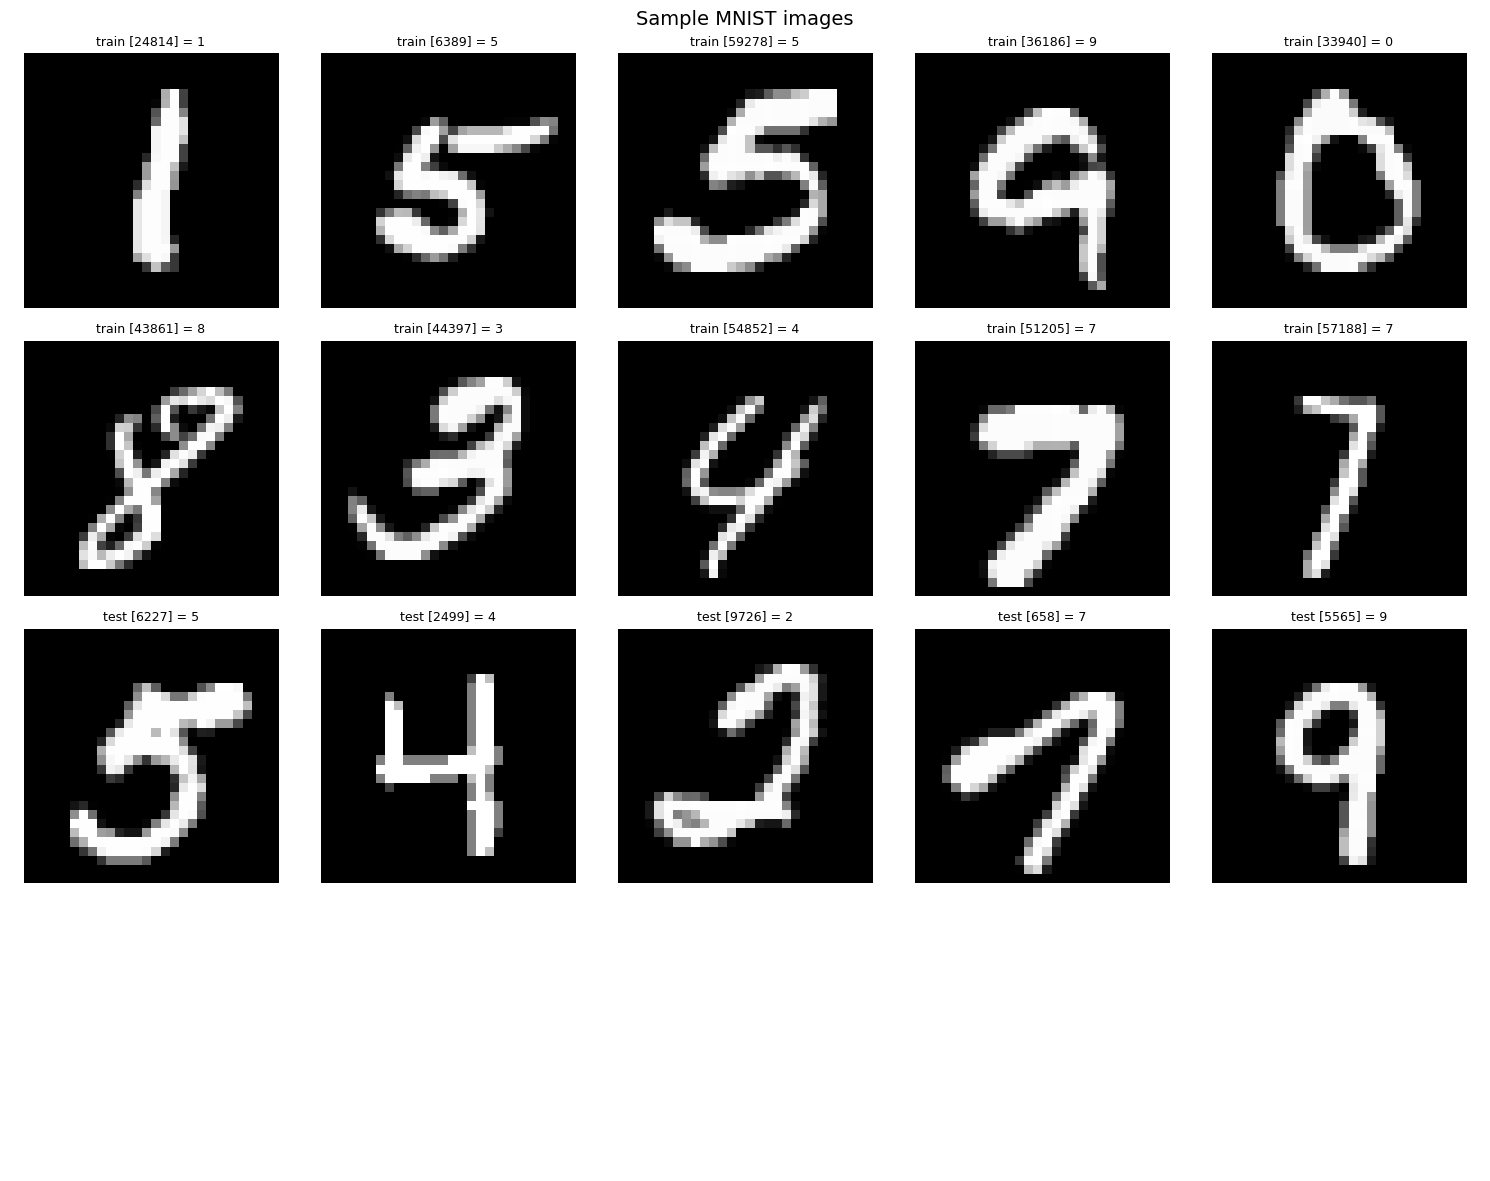

In [17]:
import os, glob

def find_file(pattern):
    results = glob.glob(f"C:\\git\\ML-hands-on-notebooks\\data\\mnist\\{pattern}", recursive=True)
    # prefer files over directories
    files = [r for r in results if os.path.isfile(r)]
    print(files)
    if not files:
        raise FileNotFoundError(f"Could not find '{pattern}' under //data/mnist//")
    return files[0]

training_images_filepath = find_file('train-images.idx3-ubyte')
training_labels_filepath = find_file('train-labels.idx1-ubyte')
test_images_filepath     = find_file('t10k-images.idx3-ubyte')
test_labels_filepath     = find_file('t10k-labels.idx1-ubyte')

print("Files resolved:")
for p in [training_images_filepath, training_labels_filepath,
          test_images_filepath, test_labels_filepath]:
    print(" ", p)

loader = MnistDataloader(
    training_images_filepath, training_labels_filepath,
    test_images_filepath,     test_labels_filepath
)
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = loader.load_data()

print(f"\nTrain images : {len(x_train_raw)}  |  labels: {len(y_train_raw)}")
print(f"Test  images : {len(x_test_raw)}   |  labels: {len(y_test_raw)}")
print(f"Image shape  : {np.array(x_train_raw[0]).shape}")

# show 15 random samples (10 train + 5 test)
images_2_show, titles_2_show = [], []
for _ in range(10):
    r = random.randint(0, len(x_train_raw)-1)
    images_2_show.append(x_train_raw[r])
    titles_2_show.append(f"train [{r}] = {y_train_raw[r]}")
for _ in range(5):
    r = random.randint(0, len(x_test_raw)-1)
    images_2_show.append(x_test_raw[r])
    titles_2_show.append(f"test [{r}] = {y_test_raw[r]}")

cols = 5
rows = int(len(images_2_show) / cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))
for ax, img, title in zip(axes.flat, images_2_show, titles_2_show):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(images_2_show):]:
    ax.axis('off')
plt.suptitle('Sample MNIST images', fontsize=14)
plt.tight_layout()
plt.show()

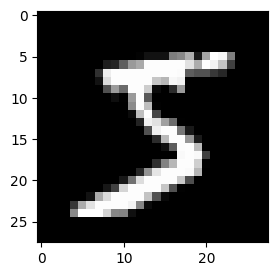

In [32]:
fig, axes = plt.subplots(1, 1, figsize=(15, 1*3))
axes.imshow(x_train_raw[0], cmap='gray')
plt.show()

x_train : (60000, 28, 28, 1)  dtype=float32
x_test  : (10000, 28, 28, 1)   dtype=float32
y_train : (60000,)  unique=[0 1 2 3 4 5 6 7 8 9]


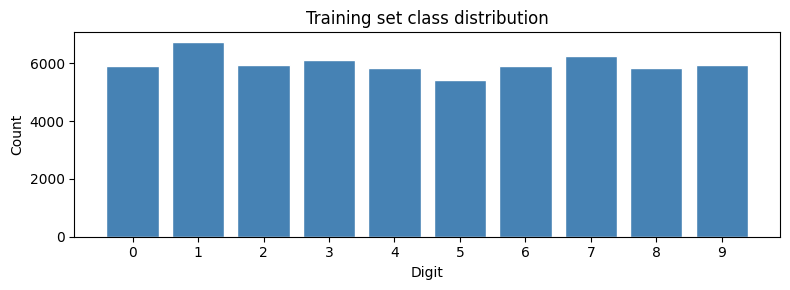

In [33]:
# ── Preprocess ───────────────────────────────────────────────────────
# convert lists → numpy arrays
x_train = np.array(x_train_raw, dtype=np.float32)
x_test  = np.array(x_test_raw,  dtype=np.float32)
y_train = np.array(y_train_raw, dtype=np.int32)
y_test  = np.array(y_test_raw,  dtype=np.int32)

# normalise pixel values to [0, 1]
x_train /= 255.0
x_test  /= 255.0

# add channel dimension → (N, 28, 28, 1) for Conv2D
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print(f"x_train : {x_train.shape}  dtype={x_train.dtype}")
print(f"x_test  : {x_test.shape}   dtype={x_test.dtype}")
print(f"y_train : {y_train.shape}  unique={np.unique(y_train)}")

# class distribution
fig, ax = plt.subplots(figsize=(8, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Digit'); ax.set_ylabel('Count')
ax.set_title('Training set class distribution')
ax.set_xticks(unique)
plt.tight_layout(); plt.show()